# Figure 4d — BLOSUM62-distance version

Same leakage analysis as `Fig4_d_decomposed_leakage.ipynb` but with **BLOSUM62
distance** on the x-axis instead of the sliding-window identity distance.

For each validation antigen, the BLOSUM62 distance is

    distance = 1 - (BLOSUM62 score of best match in pre-AF3-cutoff PDB refs)
                   / (self-BLOSUM62 score of the validation sequence)

so 0 = an identical match exists in the reference set, 1 = no similar
reference. For peptides this uses an ungapped sliding-window score; for MHC
sequences it uses global pairwise alignment with affine gaps (open=-10,
extend=-1) on the mhc_1 + mhc_2 chains concatenated.

The distances are pre-computed in `antigen_blosum62_distances.csv`. The
derivation is in the cell at the bottom of this notebook.

Spearman test is one-tailed `alternative='less'` (matching Fig 4d), so the
p-value directly tests the leakage hypothesis (negative correlation between
distance and AUC). Large p ≫ 0.05 → leakage hypothesis not supported.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = pd.read_csv('antigen_blosum62_distances.csv')
print(f"Loaded {len(df)} antigens "
      f"(class I: {(df['mhc_class']=='I').sum()}, class II: {(df['mhc_class']=='II').sum()})")
df.head()


Loaded 22 antigens (class I: 14, class II: 8)


,mhc_class,peptide,mhc_1_name,mhc_2_name,auc,pep_blosum62_dist,mhc_blosum62_dist
0,I,EAAGIGILTV,A*02:01,B2M,0.923077,0.000000,0.000000
1,I,GVYDGREHTV,A*02:01,B2M,0.538462,0.000000,0.000000
2,I,LLLDRLNQL,A*02:01,B2M,1.000000,0.785714,0.011058
3,I,LLLGIGILVL,A*02:01,B2M,1.000000,0.363636,0.000000
4,I,LPFDKATIM,B*35:01,B2M,1.000000,0.652174,0.000000


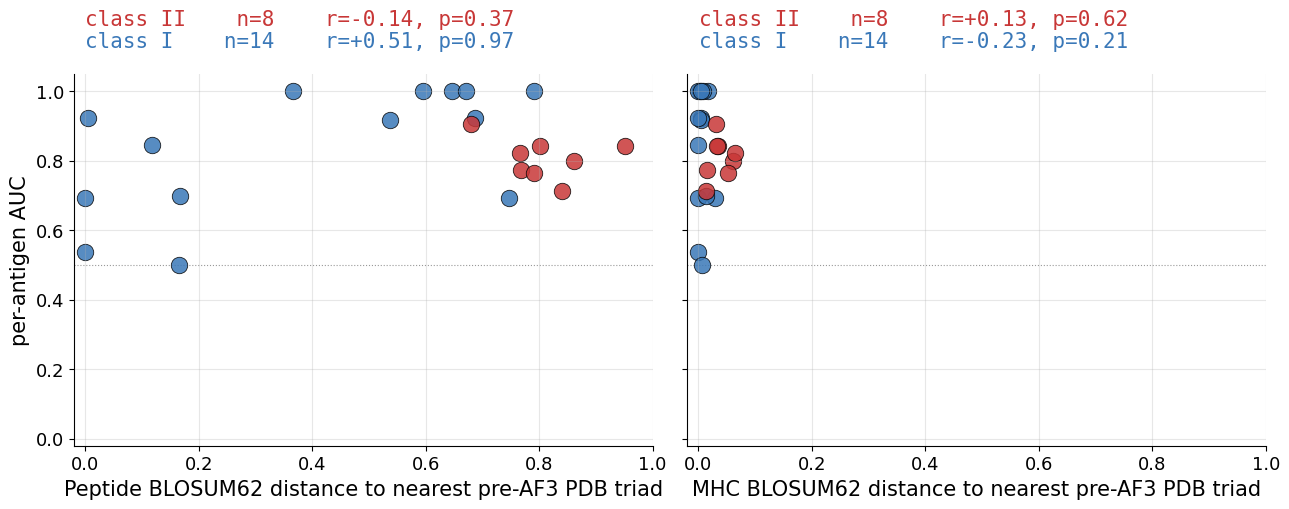

Saved: Fig4_d_decomposed_leakage_BLOSUM62.png


In [2]:
CI_BLUE = "#3a78b8"
CII_RED = "#c83737"

# Take magnitude (numerical-precision artefacts produced tiny negative MHC distances)
df['pep_blosum62_dist'] = df['pep_blosum62_dist'].abs()
df['mhc_blosum62_dist'] = df['mhc_blosum62_dist'].abs()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True, sharex=True)

for ax, (x_col, x_label) in zip(axes, [
        ('pep_blosum62_dist', 'Peptide BLOSUM62 distance to nearest pre-AF3 PDB triad'),
        ('mhc_blosum62_dist', 'MHC BLOSUM62 distance to nearest pre-AF3 PDB triad'),
    ]):
    stats_lines = []
    for cls, color in [('I', CI_BLUE), ('II', CII_RED)]:
        sub = df[df['mhc_class'] == cls].dropna(subset=[x_col, 'auc'])
        if len(sub) < 3:
            continue
        rng = np.random.default_rng(42 if cls=='I' else 1337)
        jitter = rng.uniform(-0.008, 0.008, size=len(sub))
        ax.scatter((sub[x_col] + jitter).clip(lower=0), sub['auc'],
                   s=140, color=color, edgecolor='black', linewidth=0.6,
                   alpha=0.85, label=f"class {cls}  n={len(sub)}")
        r, p = spearmanr(sub[x_col], sub['auc'], alternative='less')
        stats_lines.append((cls, color, len(sub), r, p))

    for i, (cls, color, n, r, p) in enumerate(stats_lines):
        y_off = 1.06 + 0.06 * i
        ax.text(0.02, y_off,
                f"class {cls}    n={n}    r={r:+.2f}, p={p:.2f}",
                transform=ax.transAxes, fontsize=15, color=color,
                family='monospace', va='bottom', ha='left')

    ax.set_xlabel(x_label, fontsize=15)
    ax.set_xlim(-0.02, 1.0)
    ax.set_ylim(-0.02, 1.05)
    ax.axhline(0.5, ls=':', color='0.6', lw=0.8, zorder=0)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=13)

axes[0].set_ylabel('per-antigen AUC', fontsize=15)

plt.tight_layout()
fig.subplots_adjust(top=0.80)
fig.savefig('Fig4_d_decomposed_leakage_BLOSUM62.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: Fig4_d_decomposed_leakage_BLOSUM62.png')


## How `antigen_blosum62_distances.csv` was derived

The CSV was computed once from the validation antigens
(`antigen_centric.csv`, with peptide + mhc_1_seq + mhc_2_seq) against the
pre-AF3-cutoff PDB triad reference set (filtered from
`../Figure_1_structural_benchmarking/data/pdb_triad.af3_rmsd.parquet`,
`pdb_date < 2023-01-12`).

Re-run the cell below to regenerate it from the source files.


In [3]:
# Re-derive antigen_blosum62_distances.csv from source files (one-time computation)
import pandas as pd, numpy as np
from Bio.Align import substitution_matrices, PairwiseAligner

B62 = substitution_matrices.load('BLOSUM62')
VALID_AA = set('ARNDCQEGHILKMFPSTWYV')
def clean(s): return ''.join(c for c in str(s).upper() if c in VALID_AA) if isinstance(s, str) else ''

val = pd.read_csv('antigen_centric.csv')
ref_pq = pd.read_parquet('../Figure_1_structural_benchmarking/data/pdb_triad.af3_rmsd.parquet')
ref_pq = ref_pq[ref_pq['pdb_date'] < pd.Timestamp('2023-01-12', tz='UTC')].drop_duplicates('pdb')

def pep_self(p):  return sum(B62[(a, a)] for a in p)
def pep_score(q, r):
    short, longer = (q, r) if len(q) <= len(r) else (r, q)
    return max((sum(B62[(short[i], longer[off+i])] for i in range(len(short)))
                for off in range(len(longer) - len(short) + 1)), default=-1e9)
def pep_dist(q, refs):
    q = clean(q)
    if not q: return np.nan
    return 1 - max(pep_score(q, clean(r)) for r in refs if clean(r)) / pep_self(q)

aligner = PairwiseAligner()
aligner.substitution_matrix = B62
aligner.open_gap_score = -10; aligner.extend_gap_score = -1; aligner.mode = 'global'
def mhc_concat(row):
    return clean(row.get('mhc_1_seq')) + clean(row.get('mhc_2_seq'))
def mhc_dist(q, refs):
    if not q: return np.nan
    return 1 - max(aligner.score(q, r) for r in refs if r) / sum(B62[(a, a)] for a in q)

refs = {c: {
    'pep': ref_pq[ref_pq['mhc_class']==c]['peptide'].dropna().tolist(),
    'mhc': [mhc_concat(r) for _, r in ref_pq[ref_pq['mhc_class']==c].iterrows() if mhc_concat(r)],
} for c in ['I', 'II']}

rows = []
for _, row in val.iterrows():
    cls = row['mhc_class']
    rows.append({
        'mhc_class': cls, 'peptide': row['peptide'],
        'mhc_1_name': row['mhc_1_name'], 'mhc_2_name': row['mhc_2_name'],
        'auc': row['auc'],
        'pep_blosum62_dist': pep_dist(row['peptide'], refs[cls]['pep']),
        'mhc_blosum62_dist': mhc_dist(mhc_concat(row), refs[cls]['mhc']),
    })
pd.DataFrame(rows).to_csv('antigen_blosum62_distances.csv', index=False)
print('Recomputed antigen_blosum62_distances.csv')


Recomputed antigen_blosum62_distances.csv
